In [1]:
import os

# Kaggle Access Token
os.environ['KAGGLE_API_TOKEN'] = "KGAT_88761684907cf4212adb325b8035e0e8"

# Install required packages
!pip install -q roboflow kaggle
print("Authenticated and ready!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.9 MB/s eta 0:00:00
Authenticated and ready!


In [2]:
# Dataset A: NEW Obstacles Detection Dataset (by Nayan Bebale)
print("Downloading Dataset A...")
!kaggle datasets download -d nayanbebale/obstacles-detection-datasets-yolo

# Dataset B: Potholes, Cracks, and Open Manholes / Road Hazards (by Sabid Rahman)
print("Downloading Dataset B...")
!kaggle datasets download -d sabidrahman/pothole-cracks-and-openmanhole

# Create the folders safely
!mkdir -p dataset_A
!mkdir -p dataset_B

# Unzip Dataset A
print("Unzipping Dataset A...")
!unzip -q obstacles-detection-datasets-yolo.zip -d dataset_A

# Unzip Dataset B
print("Unzipping Dataset B...")
!unzip -q pothole-cracks-and-openmanhole.zip -d dataset_B

print("Data unzipped and ready for Roboflow!")

Dataset URL: https://www.kaggle.com/datasets/nayanbebale/obstacles-detection-datasets-yolo
License(s): other
100% 263M/263M [00:03<00:00, 85.2MB/s]

Dataset URL: https://www.kaggle.com/datasets/sabidrahman/pothole-cracks-and-openmanhole
License(s): CC-BY-NC-SA-4.0
100% 1.00G/1.00G [00:11<00:00, 93.4MB/s]

Unzipping Dataset A...
Unzipping Dataset B...
Data unzipped and ready for Roboflow!


In [3]:
from roboflow import Roboflow

# Connect to Roboflow account
rf = Roboflow(api_key="p9J3iDG7hMzKFWpNI8sI")

# Define workspace
workspace = rf.workspace("alexs-workspace-rs5vl")

# Using a NEW project name so it doesn't mix with the old images
NEW_PROJECT_NAME = "visually_impaired_ai_v2"

# Upload NEW Dataset A (Nayan Bebale Obstacles)
print("Uploading Dataset A...")
workspace.upload_dataset(
    dataset_path="dataset_A",
    project_name=NEW_PROJECT_NAME,
    dataset_format="yolov8",
    project_type="object-detection"
)

# Upload Dataset B (Road Hazards)
print("Uploading Dataset B...")
workspace.upload_dataset(
    dataset_path="dataset_B",
    project_name=NEW_PROJECT_NAME,
    dataset_format="yolov8",
    project_type="object-detection"
)

print("Upload to Roboflow complete!")

Streaming output truncated to the last 5000 lines.
[UPLOADED] dataset_A/train/images/gambar-2957-_jpg.rf.bbb9230f8b5c91ed7c366afb3c12e56f.jpg (RxAMKV6vet9rtlGPp99A) [0.7s] / annotations = OK [0.6s]
[UPLOADED] dataset_A/train/images/gambar-2956-_jpg.rf.adafb369b5805a83da51cf5bca1d45da.jpg (yGnowKYKNGYmhbKEDbT8) [1.1s] / annotations = OK [0.4s]
[UPLOADED] dataset_A/train/images/gambar-2946-_jpg.rf.465f5aaa89aff62698df52a5f9b14745.jpg (592fA5PXbelponCcFtoK) [1.7s] / annotations = OK [0.8s]
[UPLOADED] dataset_A/train/images/gambar-296-_jpg.rf.19f20662ec74ee6dfb6d82650954e4df.jpg (rbvChYHQR3yGYQKhIunW) [0.6s] / annotations = OK [0.3s]
[UPLOADED] dataset_A/train/images/gambar-2960-_jpg.rf.12e9cfdee0e0a73757e14c4a2c63367b.jpg (x2kRwch3LsbpIAsEWsEN) [0.5s] / annotations = OK [0.3s]
[UPLOADED] dataset_A/train/images/gambar-2961-_jpg.rf.07c62b5c145a7645309064ac6c9865b4.jpg (RQ8Q7kQ9TCkcErUzab62) [0.6s] / annotations = OK [0.4s]
[UPLOADED] dataset_A/train/images/gambar-2959-_jpg.rf.816504d20a5370

## **New dataset after using Roboflow**

In [4]:
# Install libraries
!pip install -q roboflow ultralytics

# Download clean dataset from Roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="p9J3iDG7hMzKFWpNI8sI")
project = rf.workspace("alexs-workspace-rs5vl").project("visually_impaired_ai_v2")
version = project.version(1)
dataset = version.download("yolov8")

# Train the AI
from ultralytics import YOLO

# Load the lightweight AI model
model = YOLO('yolov8n.pt')

# Train it on new bigger dataset
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,
    imgsz=640,
    plots=True
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 10.0 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to visually_impaired_ai_v2-1 in yolov8:: 100%|██████████| 11653/11653 [00:01<00:00, 5882.62it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visually_impaired_ai_v2-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript,

Loading AI brain from: runs/detect/train/weights/best.pt
Success! Found a test image: visually_impaired_ai_v2-1/valid/images/gambar-1353-_jpg.rf.c3d643c8cd3e87668383274499439c55.jpg

image 1/1 /content/visually_impaired_ai_v2-1/valid/images/gambar-1353-_jpg.rf.c3d643c8cd3e87668383274499439c55.jpg: 640x640 1 18, 7.8ms
Speed: 1.0ms preprocess, 7.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


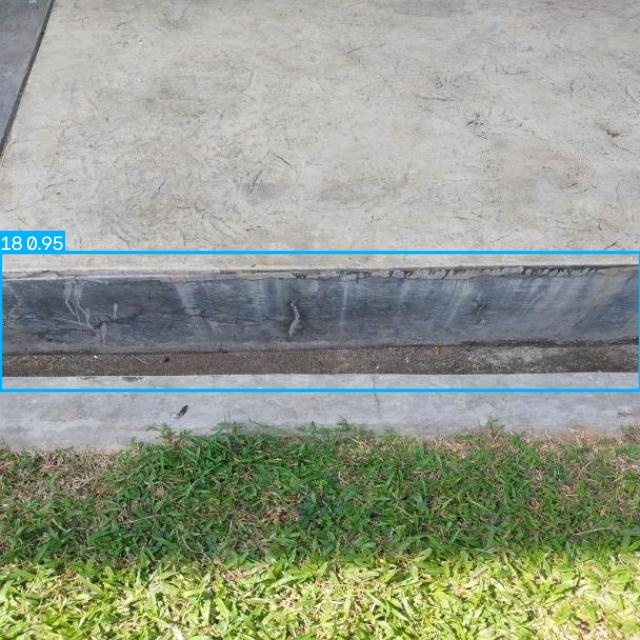

In [5]:
import glob
import os
from ultralytics import YOLO
from IPython.display import display, Image

# Automatically find the NEWEST 'best.pt' file (in case YOLO saved it in train2 or train3)
weight_files = glob.glob('runs/detect/train*/weights/best.pt')
latest_weights = max(weight_files, key=os.path.getctime)
print(f"Loading AI brain from: {latest_weights}")

# Look specifically inside new V2 dataset and grab image #99
image_list = glob.glob('visually_impaired_ai_v2-*/valid/images/*.jpg')

# Safety check: making sure we actually found images before trying to load one
if len(image_list) > 99:
    my_test_image = image_list[701]
    print(f"Success! Found a test image: {my_test_image}")

    # Load freshly trained AI
    model = YOLO(latest_weights)

    # Tell the AI to look at the image and draw boxes
    results = model.predict(source=my_test_image, save=True)

    # Grab the file name so it can be displayed
    image_name = my_test_image.split('/')[-1]

    # Display the final result right here in the notebook
    display(Image(filename=f"{results[0].save_dir}/{image_name}"))
else:
    print("Oops! Couldn't find the images. Double-check that the dataset downloaded correctly.")

Mounting to google drive

In [6]:
import os

# Create a backup folder in Google Drive
os.makedirs('/content/drive/MyDrive/YOLO_Sensor_Backup', exist_ok=True)

# Copy latest training run into that folder
!cp -r runs/detect/train /content/drive/MyDrive/YOLO_Sensor_Backup/

print("Success! Your AI brain and graphs are safely backed up to Google Drive.")

Success! Your AI brain and graphs are safely backed up to Google Drive.


Now , we don't need to train every single time and we just use the code below

In [9]:
!pip install -q roboflow ultralytics

In [30]:
!mkdir -p /content/drive/MyDrive/YOLO_Sensor_Backup
!cp /content/runs/detect/train/weights/best.pt \
    /content/drive/MyDrive/YOLO_Sensor_Backup/best.pt

print("✅ best.pt saved permanently to Google Drive!")

✅ best.pt saved permanently to Google Drive!


In [34]:
from ultralytics import YOLO
import os

model = YOLO('/content/drive/MyDrive/YOLO_Sensor_Backup/best.pt')

results = model.predict(
    source='/content/dataset_A/test/images',
    save=True,
    conf=0.4,
    max_det=100
)

print("✅ Finished testing the test dataset!")
print(f"Results saved in: {results[0].save_dir}")


image 1/504 /content/dataset_A/test/images/gambar-1002-_jpg.rf.3ef8fcc278fbb6a46fae85a1930c2103.jpg: 640x640 1 12, 7.2ms
image 2/504 /content/dataset_A/test/images/gambar-1023-_jpg.rf.5f1e3ea14830947d14e7aa1311d16650.jpg: 640x640 1 6, 7.3ms
image 3/504 /content/dataset_A/test/images/gambar-1030-_jpg.rf.145970264ba2de9e2a3fe2f1153c243f.jpg: 640x640 1 7, 7.3ms
image 4/504 /content/dataset_A/test/images/gambar-1032-_jpg.rf.814bc12b282ff6cbb4519a596922b99c.jpg: 640x640 1 20, 7.3ms
image 5/504 /content/dataset_A/test/images/gambar-105-_jpg.rf.f8ee3bcf328ada1c6df46d595ddce0e0.jpg: 640x640 1 7, 7.2ms
image 6/504 /content/dataset_A/test/images/gambar-1055-_jpg.rf.59b99da97fc8af6990dd9fe228be109b.jpg: 640x640 1 16, 1 4, 7.3ms
image 7/504 /content/dataset_A/test/images/gambar-1056-_jpg.rf.ee848035562b86fe1077888497bc32b0.jpg: 640x640 1 16, 1 4, 7.3ms
image 8/504 /content/dataset_A/test/images/gambar-1058-_jpg.rf.3f11ec08510fda9e52a79d85b72e49cf.jpg: 640x640 1 16, 1 4, 7.7ms
image 9/504 /content

Loading AI Brain...
AI is awake and ready!
Found 505 test images.
Testing image: /content/visually_impaired_ai_v2-1/test/images/gambar-1893-_jpg.rf.a680d6eb732764bb0bd5c17a66af791d.jpg

image 1/1 /content/visually_impaired_ai_v2-1/test/images/gambar-1893-_jpg.rf.a680d6eb732764bb0bd5c17a66af791d.jpg: 640x640 1 2, 7.2ms
Speed: 0.9ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-6
Prediction completed.


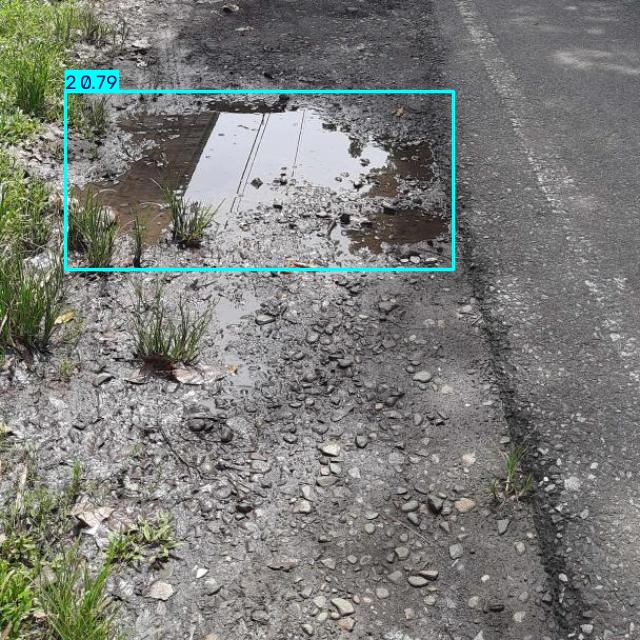

In [50]:
from ultralytics import YOLO
from IPython.display import display, Image
import glob
import os

print("Loading AI Brain...")

model = YOLO('/content/drive/MyDrive/YOLO_Sensor_Backup/best.pt')

print("AI is awake and ready!")

# Find test images from the actual Roboflow test dataset
image_list = []

for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG'):
    image_list.extend(
        glob.glob(f'/content/visually_impaired_ai_v2-1/test/images/{ext}')
    )

print(f"Found {len(image_list)} test images.")

if len(image_list) > 0:

    # Pick the third image
    my_image_path = image_list[2]

    print(f"Testing image: {my_image_path}")

    results = model.predict(
        source=my_image_path,
        save=True,
        conf=0.4
    )

    print("Prediction completed.")

    result_image = os.path.join(
        str(results[0].save_dir),
        os.path.basename(my_image_path)
    )

    display(Image(filename=result_image))

else:
    print("No test images found.")

Testing a new image: /content/visually_impaired_ai_v2-1/test/images/gambar-1094-_jpg.rf.6d418fd53c2b6049b12ab5ce0db0b5d8.jpg

image 1/1 /content/visually_impaired_ai_v2-1/test/images/gambar-1094-_jpg.rf.6d418fd53c2b6049b12ab5ce0db0b5d8.jpg: 640x640 3 17s, 7.3ms
Speed: 1.0ms preprocess, 7.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-6


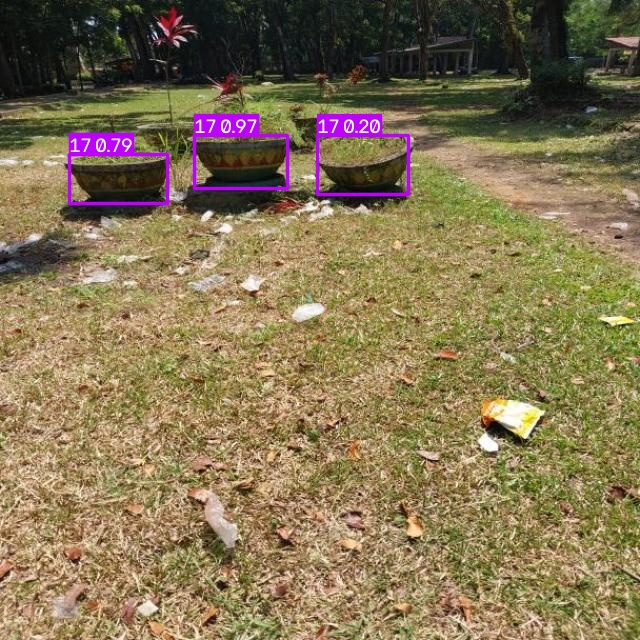

In [51]:
# Try a different image index in the list
my_image_path = image_list[65]
print(f"Testing a new image: {my_image_path}")

# Run prediction with a lower confidence threshold to catch trickier objects
results = model.predict(source=my_image_path, save=True, conf=0.10)

# Show the new result
image_name = my_image_path.split('/')[-1]
display(Image(filename=f"{results[0].save_dir}/{image_name}"))

Adapting code to webapp for phone

In [57]:
my_token = userdata.get('NGROK_TOKEN')

SecretNotFoundError: Secret NGROK_TOKEN does not exist.

In [58]:
# INSTALL PIPER & DOWNLOAD VOICE MODEL
!pip install -q ultralytics fastapi uvicorn pyngrok nest_asyncio piper-tts
!wget -q https://huggingface.co/rhasspy/piper-voices/resolve/v1.0.0/en/en_US/lessac/medium/en_US-lessac-medium.onnx
!wget -q https://huggingface.co/rhasspy/piper-voices/resolve/v1.0.0/en/en_US/lessac/medium/en_US-lessac-medium.onnx.json

# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Standard Imports
import os
import io
import wave
import base64
import nest_asyncio
import uvicorn
from PIL import Image
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from ultralytics import YOLO
from pyngrok import ngrok
from google.colab import userdata
from piper import PiperVoice

# Setup FastAPI
app = FastAPI()
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"]
)

# Load Models (YOLO Brain + Piper Voice)
model_path = '/content/drive/MyDrive/YOLO_Sensor_Backup/best.pt'
if os.path.exists(model_path):
    model = YOLO(model_path)
    print(f"YOLO Brain Loaded Successfully!")
else:
    print(f"Error: Could not find your YOLO model!")

print("🎤 Loading Piper Voice Model...")
voice = PiperVoice.load("en_US-lessac-medium.onnx")
print("Voice Ready!")

# OUR UPDATED TRUE DICTIONARY
CUSTOM_LABELS = {
    0: "pothole", 1: "cracks in the road", 2: "open manhole", 3: "vendor",
    4: "curb", 5: "crack in the road", 6: "trash bin", 7: "bench",
    8: "open manhole", 9: "car", 10: "motorcycle", 11: "person",
    12: "fence or wall", 13: "barrier", 14: "road work obstacle",
    15: "door", 16: "tree", 17: "flower pot", 18: "sewer",
    19: "stairs", 20: "pole", 21: "crosswalk"
}

# THE PREDICTION API (WITH AUDIO GENERATION)
@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    img = Image.open(io.BytesIO(contents))

    # Using 0.20 confidence to prevent the AI from being too shy
    results = model(img, conf=0.20)

    detections = []
    unique_labels = []

    for box in results[0].boxes:
        class_id = int(box.cls)
        real_word = CUSTOM_LABELS.get(class_id, f"Unknown Object ({class_id})")
        coords = box.xyxy[0].tolist()

        detections.append({
            "label": real_word,
            "box": coords
        })

        if real_word not in unique_labels:
            unique_labels.append(real_word)

    # PIPER AUDIO GENERATION
    audio_b64 = None
    if unique_labels:
        warning_text = "Warning: " + " and ".join(unique_labels[:2])

        wav_io = io.BytesIO()
        with wave.open(wav_io, 'wb') as wav_file:
            voice.synthesize(warning_text, wav_file)

        audio_b64 = base64.b64encode(wav_io.getvalue()).decode('utf-8')

    return {"detections": detections, "audio": audio_b64}

# ngrok Startup
def start_ngrok():
    try:
        from getpass import getpass

        my_token = getpass("Enter your ngrok authtoken: ")
        ngrok.kill()
        ngrok.set_auth_token(my_token)
        url = ngrok.connect(8000).public_url
        print(f"\n🚀 API LIVE AT: {url}")
        print(f"🔗 Update your VS Code HTML with: {url}/predict")
        return url
    except Exception as e:
        print(f"Ngrok Error: {e}")
        return None

if __name__ == "__main__":
    public_url = start_ngrok()
    if public_url:
        nest_asyncio.apply()
        config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
        server = uvicorn.Server(config)
        await server.serve()

Mounted at /content/drive
YOLO Brain Loaded Successfully!
🎤 Loading Piper Voice Model...
Voice Ready!
Enter your ngrok authtoken: ··········

🚀 API LIVE AT: https://purchase-tissue-wrench.ngrok-free.dev
🔗 Update your VS Code HTML with: https://purchase-tissue-wrench.ngrok-free.dev/predict


INFO:     Started server process [2308]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [2308]
